In [3]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn
import anndata as ad
import numpy as np
import pandas
import random
from scipy import stats
import palantir
import matplotlib
import matplotlib as mpl
import matplotlib.colors as mcolors
import pertpy as pt
sc._settings.settings._vector_friendly=True
matplotlib.rcParams['pdf.fonttype'] = 42
import os
os.environ['R_HOME'] = '/data1/lesliec/sneha/anaconda/envs/sc-env/lib/R'
from rpy2.rinterface_lib import openrlib
openrlib.R_HOME = '/data1/lesliec/sneha/anaconda/envs/sc-env/lib/R'

In [4]:
adata = sc.read_h5ad('./data/scrna.h5ad')

In [23]:
adata.obs['celltype_new'].value_counts()

celltype_new
CD4_3 Mem             4416
CD8_2 GZMK+           2796
CD8_3 GZMB+           2743
CD8_1 Early Eff       2702
CD4_1 IEG             2156
CD4_4 GZMK+           2096
CD8_4 Late GZMB+      1505
CD8_0 Early Prolif    1415
CD4_0 Early Mem        642
CD4_2 Early Treg       164
Name: count, dtype: int64

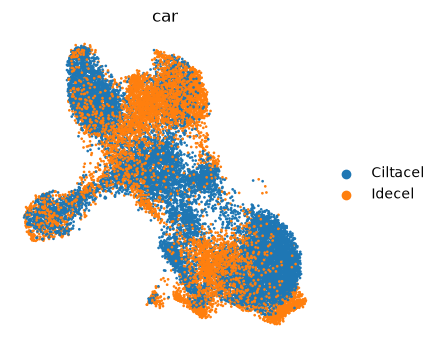

In [5]:
sc.pl.umap(adata, color='car', size=15, frameon=False)

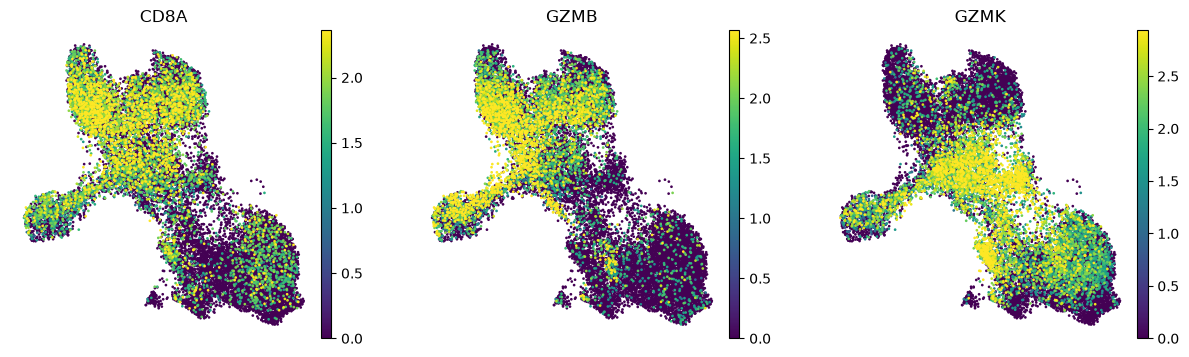

In [6]:
sc.pl.umap(adata, color=['CD8A', 'GZMB', 'GZMK'], vmax='p95', size=15, frameon=False, cmap='viridis')

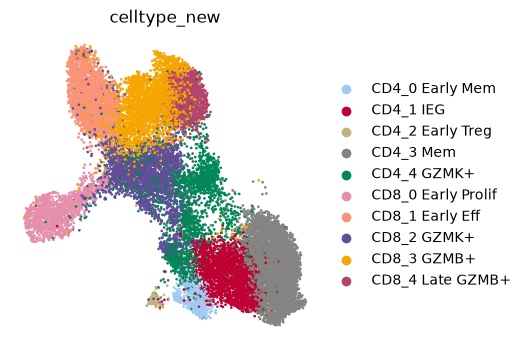

In [7]:
sc.pl.umap(adata, color='celltype_new', size=15, frameon=False)

R callback write-console: Capping the NB dispersion(s) to be no larger than 4.
  
/data1/lesliec/sneha/anaconda/envs/sc-env/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 21.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/lesliec/sneha/anaconda/envs/sc-env/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 20.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/lesliec/sneha/anaconda/envs/sc-env/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 7.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/lesliec/sneha/anaconda/envs/sc-env/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want 

Text(0.5, 1.0, 'Idecel vs. Ciltacel')

/data1/lesliec/sneha/anaconda/envs/sc-env/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 21.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/lesliec/sneha/anaconda/envs/sc-env/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 20.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/lesliec/sneha/anaconda/envs/sc-env/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 7.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/lesliec/sneha/anaconda/envs/sc-env/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWar

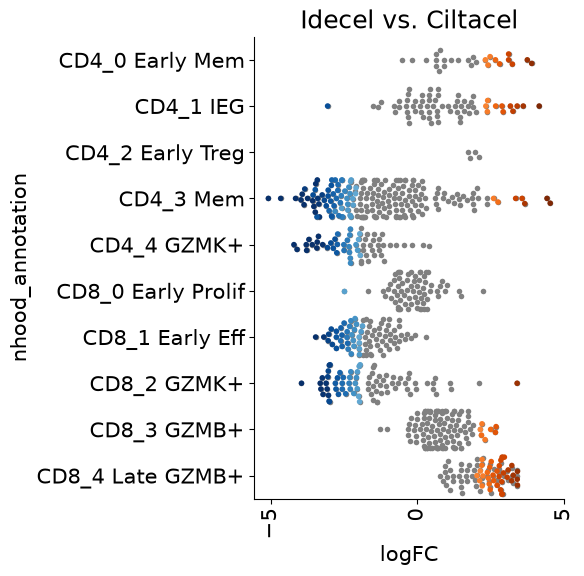

In [9]:
## Initialize object for Milo analysis
milo = pt.tl.Milo()
mdata = milo.load(adata)

sc.pp.neighbors(mdata['rna'], use_rep="X_pca", n_neighbors=50)
milo.make_nhoods(mdata['rna'], prop=0.1)

mdata['rna'].obs['Sample_type'] = [r['pt_id'] + '_' + r['celltype_new'] for i,r in mdata['rna'].obs.iterrows()]
mdata = milo.count_nhoods(mdata, sample_col="Sample_type")
mdata["rna"].obs["car"] = mdata["rna"].obs["car"].cat.reorder_categories(["Ciltacel", "Idecel"])
milo.da_nhoods(mdata, design="~car", solver='edger')
milo.build_nhood_graph(mdata)
milo.annotate_nhoods(mdata, anno_col="celltype_new")

mdata["milo"].var["nhood_annotation"] = mdata["milo"].var["nhood_annotation"].values.tolist()
mdata["milo"].var.loc[mdata["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

df = mdata['milo'].var.copy()
df['-log10(SpatialFDR)'] = -np.log10(df['SpatialFDR']) # ['FDR'])
df.loc[df['logFC'] < 0, '-log10(SpatialFDR)'] = -df[df['logFC'] < 0]['-log10(SpatialFDR)']

min_max = min(abs(df['-log10(SpatialFDR)'].min()), df['-log10(SpatialFDR)'].max())
norm = plt.Normalize(-min_max, min_max) # -0.3, 0.3) # df_tumor_t['-log10(FDR)'].min(), df_tumor_t['-log10(FDR)'].max())
bottom = mpl.colormaps['Oranges'].resampled(128)
top = mpl.colormaps['Blues_r'].resampled(128)

newcolors = np.vstack((top(np.linspace(0, 1, 128)),
                       bottom(np.linspace(0, 1, 128))))
newcmp = mcolors.ListedColormap(newcolors, name='OrangeBlue')


sm = plt.cm.ScalarMappable(cmap=newcmp, norm=norm)

plt.figure(figsize=(4,6))
plt.rcParams.update({'font.size': 15})

g = seaborn.swarmplot(data=df, x="logFC", y="nhood_annotation", color='grey',
                     order=['CD4_0 Early Mem',
                             'CD4_1 IEG',
                             'CD4_2 Early Treg',
                             'CD4_3 Mem',
                                'CD4_4 GZMK+',
                                 'CD8_0 Early Prolif',
                                 'CD8_1 Early Eff',
                                 'CD8_2 GZMK+',
                                     'CD8_3 GZMB+',
                                 'CD8_4 Late GZMB+'],
                     size=4)

g = seaborn.swarmplot(data=df[df['SpatialFDR'] < 0.05], 
                      x="logFC", y="nhood_annotation", hue='-log10(SpatialFDR)', palette=newcmp, hue_norm=norm,
                     order=['CD4_0 Early Mem',
                             'CD4_1 IEG',
                             'CD4_2 Early Treg',
                             'CD4_3 Mem',
                                'CD4_4 GZMK+',
                                 'CD8_0 Early Prolif',
                                 'CD8_1 Early Eff',
                                 'CD8_2 GZMK+',
                                     'CD8_3 GZMB+',
                                 'CD8_4 Late GZMB+'],
                     size=4)
sm.set_array([])
plt.gca().get_legend().remove()
plt.gca().tick_params(axis='x', rotation=90)
plt.title('Idecel vs. Ciltacel')

In [10]:
adata_cd4 = adata[adata.obs['celltype_new'].str.startswith('CD4')].copy()
adata_cd8 = adata[adata.obs['celltype_new'].str.startswith('CD8')].copy()

In [11]:
tbl_gbm = pandas.read_csv('data/supp_tbl_1_T_cells_cohort_Fig1.csv', sep=',')
tbl_gbm.loc[tbl_gbm['cluster']=='C1', 'cluster'] = 'CD4_Naive'
tbl_gbm.loc[tbl_gbm['cluster']=='C2', 'cluster'] = 'CD8_Naive'
tbl_gbm.loc[tbl_gbm['cluster']=='C3', 'cluster'] = 'CD4_TCM'
tbl_gbm.loc[tbl_gbm['cluster']=='C4', 'cluster'] = 'CD4_TEM'
tbl_gbm.loc[tbl_gbm['cluster']=='C5', 'cluster'] = 'CD4_activated_1'
tbl_gbm.loc[tbl_gbm['cluster']=='C6', 'cluster'] = 'CD4_activated_2'
tbl_gbm.loc[tbl_gbm['cluster']=='C7', 'cluster'] = 'CD4_activated_3'
tbl_gbm.loc[tbl_gbm['cluster']=='C8', 'cluster'] = 'CD4_GZMK'
tbl_gbm.loc[tbl_gbm['cluster']=='C9', 'cluster'] = 'CD8_GZMK_NR4A2lo'
tbl_gbm.loc[tbl_gbm['cluster']=='C10', 'cluster'] = 'CD8_GZMK_NR4A2hi'
tbl_gbm.loc[tbl_gbm['cluster']=='C11', 'cluster'] = 'CD8_TRM'
tbl_gbm.loc[tbl_gbm['cluster']=='C12', 'cluster'] = 'TEMRA'
tbl_gbm.loc[tbl_gbm['cluster']=='C13', 'cluster'] = 'MAIT-like'
tbl_gbm.loc[tbl_gbm['cluster']=='C14', 'cluster'] = 'CD4_Treg'
tbl_gbm.loc[tbl_gbm['cluster']=='C15', 'cluster'] = 'T_Prolif'
tbl_gbm.loc[tbl_gbm['cluster']=='C16', 'cluster'] = 'Stress'
tbl_gbm = tbl_gbm.iloc[np.argsort(-tbl_gbm['avg_log2FC'].values)]

cd4_clusters = tbl_gbm[~tbl_gbm['cluster'].str.startswith('CD8')]['cluster'].unique()
cd8_clusters = tbl_gbm[~tbl_gbm['cluster'].str.startswith('CD4')]['cluster'].unique()

wang_cd4_gzmk_top20 = tbl_gbm[(tbl_gbm['cluster']=='CD4_GZMK') & 
                                (tbl_gbm['avg_log2FC'] > 0.5) & (tbl_gbm['p_val_adj'] < 1e-10)]['gene'].values[:20]

wang_cd8_gzmk_top20 = tbl_gbm[(tbl_gbm['cluster']=='CD8_GZMK_NR4A2lo') & 
                                (tbl_gbm['avg_log2FC'] > 0.5) & (tbl_gbm['p_val_adj'] < 1e-10)]['gene'].values[:20]

In [12]:
sc.tl.score_genes(adata_cd4, wang_cd4_gzmk_top20, score_name='Wang_CD4_GZMK')
sc.tl.score_genes(adata_cd8, wang_cd8_gzmk_top20, score_name='Wang_CD8_GZMK_NR4A2lo')

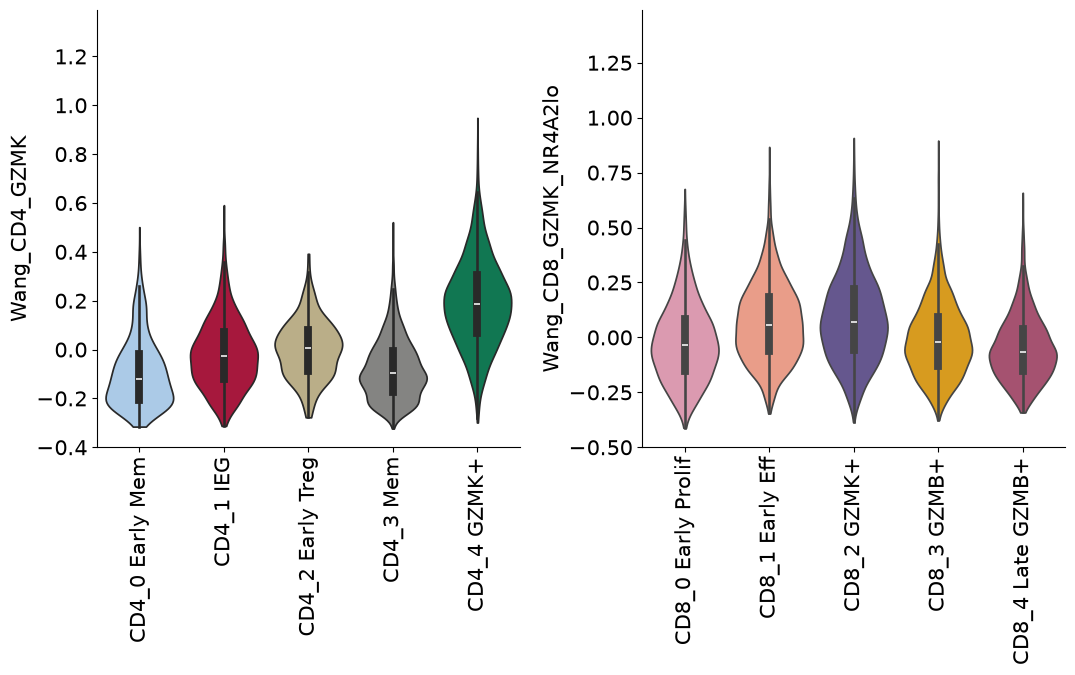

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 7))
sc.pl.violin(adata_cd4, 'Wang_CD4_GZMK', groupby='celltype_new', rotation=90, stripplot=False, inner='box', ax=ax[0], show=False)
sc.pl.violin(adata_cd8, 'Wang_CD8_GZMK_NR4A2lo', groupby='celltype_new', rotation=90, stripplot=False, inner='box', ax=ax[1], show=False)
ax[0].set_ylim((-0.4, 1.39))
ax[1].set_ylim((-0.5, 1.49))
plt.tight_layout()

In [14]:
for c in adata_cd4.obs.celltype_new.unique():
    if c == 'CD4_4 GZMK+': continue
    v1 = adata_cd4[adata_cd4.obs['celltype_new']==c].obs['Wang_CD4_GZMK'].values
    v2 = adata_cd4[adata_cd4.obs['celltype_new']=='CD4_4 GZMK+'].obs['Wang_CD4_GZMK'].values
    _, pv = stats.mannwhitneyu(v1, v2)
    print(c, pv)

CD4_1 IEG 1.9285552382509753e-294
CD4_0 Early Mem 9.315471538668133e-201
CD4_3 Mem 0.0
CD4_2 Early Treg 9.77053675742725e-41


In [15]:
for c in adata_cd8.obs.celltype_new.unique():
    if c == 'CD8_2 GZMK+': continue
    v1 = adata_cd8[adata_cd8.obs['celltype_new']==c].obs['Wang_CD8_GZMK_NR4A2lo'].values
    v2 = adata_cd8[adata_cd8.obs['celltype_new']=='CD8_2 GZMK+'].obs['Wang_CD8_GZMK_NR4A2lo'].values
    _, pv = stats.mannwhitneyu(v1, v2)
    print(c, pv)

CD8_4 Late GZMB+ 5.2900543506481876e-111
CD8_3 GZMB+ 3.694321601370166e-76
CD8_0 Early Prolif 8.936850511284755e-64
CD8_1 Early Eff 0.0005186998314708785


In [17]:
adata_cd4_t = adata[(adata.obs['celltype_new'].str.startswith('CD4')) & (~adata.obs['celltype_new'].str.contains('Treg'))].copy()
adata_cd8_t = adata[adata.obs['celltype_new'].str.startswith('CD8')].copy()

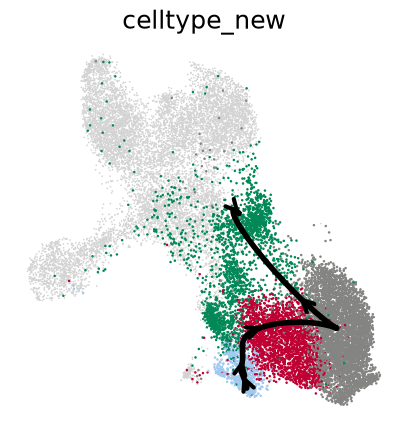

In [18]:
plt.figure(figsize=(5,5))
sc.pl.umap(adata, show=False, ax=plt.gca())
palantir.plot.plot_trajectories(adata_cd4_t, pseudotime_interval=(0, .9), ax=plt.gca(), cell_color='celltype_new',
                               smoothness=0.5, n_arrows=5, palantir_fates_colors=['black'], pseudo_time_key='palantir_pseudotime_cd4',
                               masks_key='branch_masks_CD4')
plt.gca().get_legend().remove()

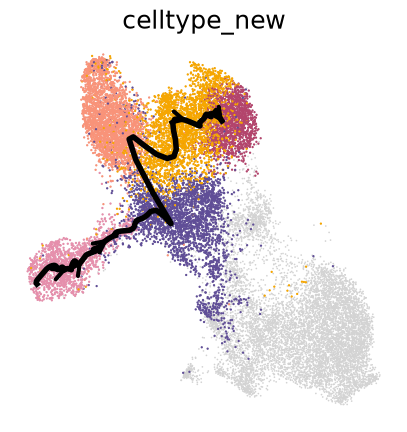

In [19]:
plt.figure(figsize=(5,5))
sc.pl.umap(adata, show=False, ax=plt.gca())
palantir.plot.plot_trajectories(adata_cd8_t, pseudotime_interval=(0, .9), ax=plt.gca(), cell_color='celltype_new',
                               smoothness=0.1, n_arrows=5, palantir_fates_colors=['black'], pseudo_time_key='palantir_pseudotime_cd8',
                               masks_key='branch_masks_CD8')

plt.gca().get_legend().remove()

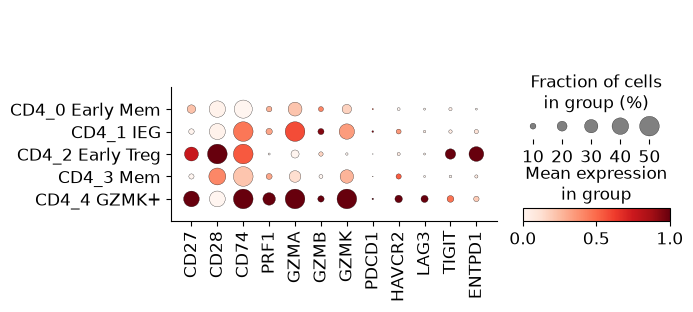

In [21]:
sc.pl.dotplot(adata_cd4, ['CD27', 'CD28', 'CD74', 'PRF1', 'GZMA', 'GZMB', 'GZMK', 'PDCD1', 'HAVCR2', 
                          'LAG3', 'TIGIT', 'ENTPD1'], groupby='celltype_new', standard_scale='var', dot_max=0.5)

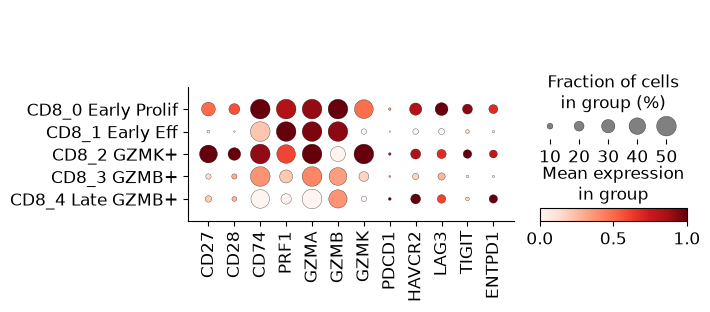

In [22]:
sc.pl.dotplot(adata_cd8, ['CD27', 'CD28', 'CD74', 'PRF1', 'GZMA', 'GZMB', 'GZMK', 'PDCD1', 'HAVCR2', 
                          'LAG3', 'TIGIT', 'ENTPD1'], groupby='celltype_new', standard_scale='var', dot_max=0.5)